In [ ]:
from pathlib import Path
import sys
import random
import copy
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, average_precision_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from DataProcessing import Dataprocessing, Sensors, Actuators, NPI_ATTACK_IDS
from ModelTraining import LSTMAutoencoder, train_one_epoch, evaluate_reconstruction_loss
print(f"Using preprocessing module: {Dataprocessing.__module__}")
print(f"Sensor features: {len(Sensors)}")
print(f"Actuator features: {len(Actuators)}")
print(f"NPI attacks excluded from dynamic recovery: {sorted(NPI_ATTACK_IDS)}")

import warnings
warnings.filterwarnings('ignore')

device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print("device:", device)

Using preprocessing module: DataProcessing
Sensor features: 25
Actuator features: 26
NPI attacks excluded from dynamic recovery: [5, 9, 12, 15, 18]
device: mps


In [2]:
SEQ_LEN = 64
STRIDE = 5
INPUT_DIM = 51

BATCH_SIZE = 512
EPOCHS = 100
PATIENCE = 8
RANDOM_SEED = 42

# MinMax
BEST_PARAMS = {
    "score_mode": "max",
    "conv_channels": 64,
    "kernel_size": 3,
    "hidden_size": 64,
    "num_layers": 4,
    "dropout": 0.49521204489910164,
    "bidirectional": True,
    "learning_rate": 0.0002654334209893315,
    "weight_decay": 5.414328125404531e-05,
    "threshold_percentile": 96.87360466212871,
    "top_k": 5,
}

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_global_seed(RANDOM_SEED)

In [3]:
start_time = pd.to_datetime("2015-12-23 12:00:00")

X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, metadata = Dataprocessing(
    start_time=start_time,
    SEQ_LEN=SEQ_LEN,
    STRIDE=STRIDE,
    return_metadata=True,
    # dataset_dir=DATASET_DIR,
    sensor_alpha=0.1,
    baseline_k=3.0,
    sensor_recovery_ratio=0.8,
    recovery_hold_windows=5,
)

attack_window_df = metadata["attack_window_df"].copy()
recovery_segments = metadata["recovery_segments"].copy()
fixed_recovery_seconds = tuple(metadata["fixed_recovery_seconds"])
fixed_recovery_cols = [f"label_recovery_{seconds}s" for seconds in fixed_recovery_seconds]

display(recovery_segments[[
    "attack_id", "attack_name", "start", "end", "recovery_end",
    "recovery_seconds", "key_sensors", "critical_actuators",
    "used_for_dynamic_label",
]].head())



------------------------- Original Data -------------------------
Normal Data = (495000, 66)
Attack Data = (449919, 66)

------------------------- Processing ... -------------------------
Normal data = (424800, 66)
Skip data = 70200
Number of total data = (874719, 65)
train_set = (339840, 66)
val_set = (42480, 66)
test_set = (492399, 66)
Test data has 438514 normal data and 53885 abnomaly data.
train gaps: 0
val gaps: 0
test gaps: 1
sensor features (25): ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601']
actuator features (26): ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'P401', 'P402', 'P403', 'P404', 'UV401', 'P501', 'P502', 'P601', 'P602', 'P603']

------------------------- Recovery-aware Labels

,attack_id,attack_name,start,end,recovery_end,recovery_seconds,key_sensors,critical_actuators,used_for_dynamic_label
0,1,Attack1,2015-12-28 10:29:14,2015-12-28 10:44:53,2015-12-28 10:46:17,84.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P...",True
1,2,Attack2,2015-12-28 10:51:08,2015-12-28 10:58:30,2015-12-28 10:59:54,84.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P...",True
2,3,Attack3,2015-12-28 11:22:00,2015-12-28 11:28:22,2015-12-28 11:38:01,579.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P...",True
3,4,Attack4,2015-12-28 11:47:39,2015-12-28 11:54:08,2015-12-28 11:55:32,84.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P...",True
4,6,Attack6,2015-12-28 12:00:55,2015-12-28 12:04:10,2015-12-28 12:05:34,84.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P...",True


In [4]:
# numpy -> tensor，並塑形
train_dataset = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(np.zeros(len(X_train_seq), dtype=np.int64)))
val_dataset = TensorDataset(torch.from_numpy(X_val_seq), torch.from_numpy(np.zeros(len(X_val_seq), dtype=np.int64)))
test_dataset = TensorDataset(torch.from_numpy(X_test_seq), torch.from_numpy(y_test_seq))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [19]:
history = {"train_loss": [], "val_loss": []}

def compute_window_score(reconstruction, batch_x, mode="mean", top_k=5):
    point_error = (reconstruction - batch_x) ** 2
    timestep_error = point_error.mean(dim=2)

    if mode == "mean":
        return timestep_error.mean(dim=1)
    if mode == "max":
        return timestep_error.max(dim=1).values
    if mode == "topk":
        k = min(top_k, timestep_error.shape[1])
        topk_vals = torch.topk(timestep_error, k=k, dim=1).values
        return topk_vals.mean(dim=1)

    raise ValueError(f"Unsupported mode: {mode}")


def get_reconstruction_errors(model, data_array: np.ndarray, device, batch_size: int = 512, score_mode: str = "topk", top_k: int = 7):
    model.eval()
    scores = []
    dataset = TensorDataset(torch.from_numpy(data_array).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            reconstruction = model(batch_x)
            batch_error = compute_window_score(reconstruction, batch_x, mode=score_mode, top_k=top_k)
            scores.append(batch_error.detach().cpu().numpy())

    return np.concatenate(scores)


def fit_model(params, capture_history=False):
    seed = int(params.get("seed", RANDOM_SEED))
    set_global_seed(seed)

    model = LSTMAutoencoder(
        input_dim=INPUT_DIM,
        conv_channels=params["conv_channels"],
        kernel_size=params["kernel_size"],
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        bidirectional=params["bidirectional"],
    ).to(device)
    print(model)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

    local_history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state_dict = None
    wait = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_reconstruction_loss(model, val_loader, criterion, device)

        if capture_history:
            local_history["train_loss"].append(train_loss)
            local_history["val_loss"].append(val_loss)

        print(f"Epoch [{epoch:02d}/{EPOCHS}] train_loss={train_loss:.6f} val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state_dict)
    return model, best_val_loss, local_history


def compute_binary_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }



In [20]:
best_params = dict(BEST_PARAMS)
best_params["seed"] = RANDOM_SEED

print("Fixed best params from Optuna AttackGroupCV study")
print(best_params)



Fixed best params from Optuna AttackGroupCV study
{'score_mode': 'max', 'conv_channels': 64, 'kernel_size': 3, 'hidden_size': 64, 'num_layers': 4, 'dropout': 0.49521204489910164, 'bidirectional': True, 'learning_rate': 0.0002654334209893315, 'weight_decay': 5.414328125404531e-05, 'threshold_percentile': 96.87360466212871, 'top_k': 5, 'seed': 42}


In [21]:
best_params = dict(BEST_PARAMS)
best_params["seed"] = RANDOM_SEED

best_model, best_val_loss, history = fit_model(best_params, capture_history=True)

threshold_errors = get_reconstruction_errors(
    best_model,
    X_val_seq,
    device,
    batch_size=BATCH_SIZE,
    score_mode=best_params["score_mode"],
    top_k=best_params["top_k"],
)

threshold = np.percentile(threshold_errors, best_params["threshold_percentile"])

attack_errors = get_reconstruction_errors(
    best_model,
    X_test_seq,
    device,
    batch_size=BATCH_SIZE,
    score_mode=best_params["score_mode"],
    top_k=best_params["top_k"],
)

y_true = attack_window_df["label"].to_numpy(dtype=np.int64)
y_pred = (attack_errors > threshold).astype(np.int64)

evaluation_df = attack_window_df.copy()
evaluation_df["error"] = attack_errors
evaluation_df["threshold"] = threshold
evaluation_df["y_pred"] = y_pred

print(f"Best val loss: {best_val_loss:.6f}")
print(f"Threshold percentile: {best_params['threshold_percentile']:.4f}")
print(f"Threshold: {threshold:.6f}")
print(f"Official F1: {f1_score(y_true, y_pred, zero_division=0):.4f}")

LSTMAutoencoder(
  (feature_extractor): ConvFeatureExtractor(
    (net): Sequential(
      (0): Conv1d(51, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.49521204489910164, inplace=False)
      (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
    )
  )
  (encoder): Encoder(
    (lstm): LSTM(64, 64, num_layers=4, batch_first=True, dropout=0.49521204489910164, bidirectional=True)
  )
  (decoder): Decoder(
    (lstm): LSTM(64, 64, num_layers=4, batch_first=True, dropout=0.49521204489910164, bidirectional=True)
    (output_layer): Linear(in_features=128, out_features=64, bias=True)
  )
  (reconstruction_head): ReconstructionHead(
    (proj): Conv1d(64, 51, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)


KeyboardInterrupt: 

In [11]:
y_true = attack_window_df["label"].to_numpy(dtype=np.int64)
y_pred = (attack_errors > threshold).astype(np.int64)

evaluation_df = attack_window_df.copy()
evaluation_df["error"] = attack_errors
evaluation_df["threshold"] = threshold
evaluation_df["y_pred"] = y_pred

print(f"Best val loss: {best_val_loss:.6f}")
print(f"Threshold percentile: {best_params['threshold_percentile']:.4f}")
print(f"Threshold: {threshold:.6f}")
print(f"Official F1: {f1_score(y_true, y_pred, zero_division=0):.4f}")

Best val loss: 0.003634
Threshold percentile: 96.8736
Threshold: 0.032084
Official F1: 0.2606


In [ ]:
def compute_point_metrics(eval_df, label_col="label", pred_col="y_pred", ignore_col=None):

    if ignore_col is None:
        mask = np.ones(len(eval_df), dtype=bool)
    else:
        mask = eval_df[ignore_col].to_numpy(dtype=int) == 0

    y_true = eval_df.loc[mask, label_col].to_numpy(dtype=np.int64)
    y_pred = eval_df.loc[mask, pred_col].to_numpy(dtype=np.int64)
    scores = eval_df.loc[mask, "error"].to_numpy(dtype=float)

    auc_pr = average_precision_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan

    return {
        "Evaluated Windows": int(mask.sum()),
        "Ignored Windows": int((~mask).sum()),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "AUC-PR": auc_pr,
    }


def format_metric_df(rows):

    df = pd.DataFrame(rows)
    num_cols = ["Accuracy", "Precision", "Recall", "F1-score", "AUC-PR"]
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].round(4)

    return df


# Table1：Official-label evaluation
table1 = format_metric_df([
    {
        "Setting": "Official-label",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col=None)
    }
])

display(table1)
# table1.to_csv("./results/table1_official_label_evaluation.csv", index=False)


# Table2：Delay-aware / recovery-aware evaluation
table2_rows = [
    {
        "Setting": "1. Official label",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col=None)
    },
    {
        "Setting": "2. Attack-period-only",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col="ignore_attack_period_only")
    },
    {
        "Setting": "3. Post-attack ignore 10 min",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col="ignore_buffer_10m")
    },
    {
        "Setting": "4. Post-attack ignore 30 min",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col="ignore_buffer_30m")
    },
    {
        "Setting": "5. Post-attack ignore 60 min",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col="ignore_buffer_60m")
    },
    {
        "Setting": "6. Dynamic recovery-aware",
        **compute_point_metrics(evaluation_df, label_col="label_dynamic", pred_col="y_pred", ignore_col=None)
    },
]

table2 = format_metric_df(table2_rows)
display(table2)
# table2.to_csv("table2_delay_recovery_evaluation.csv", index=False)

,Setting,Evaluated Windows,Ignored Windows,Accuracy,Precision,Recall,F1-score,AUC-PR
0,Official-label,98455,0,0.3813,0.1508,0.9586,0.2606,0.726


,Setting,Evaluated Windows,Ignored Windows,Accuracy,Precision,Recall,F1-score,AUC-PR
0,1. Official label,98455,0,0.3813,0.1508,0.9586,0.2606,0.7260
1,2. Recovery 30s,98455,0,0.2816,0.0076,0.8565,0.0151,0.0223
2,3. Recovery 60s,98455,0,0.2828,0.0099,0.8465,0.0196,0.0319
3,4. Recovery 90s,98455,0,0.2840,0.0121,0.8367,0.0238,0.0440
4,5. Recovery 120s,98455,0,0.2851,0.0142,0.8296,0.0280,0.0466
5,6. Dynamic recovery-aware,98455,0,0.5788,0.4281,0.9757,0.5951,0.8246


In [13]:
def find_first_consecutive_detection(times, preds, min_consecutive_windows=2):

    count = 0
    first_time = None

    for t, p in zip(times, preds):
        if int(p) == 1:
            if count == 0:
                first_time = t
            count += 1
            if count >= min_consecutive_windows:
                return first_time
        else:
            count = 0
            first_time = None

    return None


def build_per_attack_event_table(eval_df, recovery_segments, min_consecutive_windows=2):

    rows = []
    for _, seg in recovery_segments.iterrows():
        attack_id = int(seg["attack_id"])
        attack_name = seg["attack_name"]

        if attack_id in NPI_ATTACK_IDS:
            continue

        attack_start = pd.Timestamp(seg["start"])
        attack_end = pd.Timestamp(seg["end"])
        recovery_end = pd.Timestamp(seg["recovery_end"])

        mask = (
            (pd.to_datetime(eval_df["window_end"]) >= attack_start) &
            (pd.to_datetime(eval_df["window_start"]) <= recovery_end)
        )
        grp = eval_df.loc[mask].copy()

        first_detection_time = find_first_consecutive_detection(
            times=pd.to_datetime(grp["window_end"]).tolist(),
            preds=grp["y_pred"].to_numpy(dtype=np.int64),
            min_consecutive_windows=min_consecutive_windows,
        )

        detected = first_detection_time is not None
        ttd_seconds = (
            (pd.Timestamp(first_detection_time) - attack_start).total_seconds()
            if detected else np.nan
        )

        rows.append({
            "Attack ID": attack_id,
            "Attack": attack_name,
            "Official Start": attack_start,
            "Official End": attack_end,
            "Dynamic Recovery End": recovery_end,
            "Recovery Seconds": int(seg["recovery_seconds"]),
            "Windows": len(grp),
            "Positive Windows": int(grp["label_dynamic"].sum()) if len(grp) > 0 else 0,
            "Detected": detected,
            "First Detection Time": first_detection_time,
            "TTD Seconds": ttd_seconds,
            "Key Sensors": seg["key_sensors"],
            "Critical Actuators": seg["critical_actuators"],
        })

    return pd.DataFrame(rows)


def count_false_alarm_events(eval_df, label_col="label_dynamic", pred_col="y_pred"):

    normal_df = eval_df[eval_df[label_col] == 0].copy()
    if len(normal_df) == 0:
        return 0, 0.0

    normal_df = normal_df.sort_values("window_end").reset_index(drop=True)
    pred = normal_df[pred_col].to_numpy(dtype=np.int64)
    times = pd.to_datetime(normal_df["window_end"])

    false_alarm_events = 0
    in_alarm = False

    for i, p in enumerate(pred):
        if p == 1 and not in_alarm:
            false_alarm_events += 1
            in_alarm = True
        elif p == 0:
            in_alarm = False

    normal_hours = len(normal_df) * STRIDE / 3600.0

    return false_alarm_events, normal_hours


# Table3：per-attack event recall
table3 = build_per_attack_event_table(
    evaluation_df,
    recovery_segments,
    min_consecutive_windows=2,
)

display(table3)
table3.to_csv("./results/table3_per_attack_event_recall.csv", index=False)


# Table4：Event-level evaluation
detected_count = int(table3["Detected"].sum())
total_events = int(len(table3))
missed_attacks = table3.loc[~table3["Detected"], "Attack"].tolist()

fa_events, normal_hours = count_false_alarm_events(
    evaluation_df,
    label_col="label_dynamic",
    pred_col="y_pred",
)

table4 = pd.DataFrame([{
    "Event Recall": detected_count / total_events if total_events > 0 else np.nan,
    "Detected Events": detected_count,
    "Total Events": total_events,
    "Median Time-to-Detection": table3["TTD Seconds"].median(),
    "Mean Time-to-Detection": table3["TTD Seconds"].mean(),
    "Missed Attacks": ", ".join(missed_attacks) if len(missed_attacks) > 0 else "None",
    "False Alarm Events": fa_events,
    "Normal Hours": normal_hours,
    "False Alarms per Hour": fa_events / normal_hours if normal_hours > 0 else np.nan,
}])

display(table4)
table4.to_csv("./results/table4_event_level_evaluation.csv", index=False)

,Attack ID,Attack,Official Start,Official End,Dynamic Recovery End,Recovery Seconds,Windows,Positive Windows,Detected,First Detection Time,TTD Seconds,Key Sensors,Critical Actuators
0,1,Attack1,2015-12-28 10:29:14,2015-12-28 10:44:53,2015-12-28 10:46:17,84,217,217,True,2015-12-28 10:29:18,4.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."
1,2,Attack2,2015-12-28 10:51:08,2015-12-28 10:58:30,2015-12-28 10:59:54,84,118,118,True,2015-12-28 10:51:08,0.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."
2,3,Attack3,2015-12-28 11:22:00,2015-12-28 11:28:22,2015-12-28 11:38:01,579,205,205,True,2015-12-28 11:23:13,73.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."
3,4,Attack4,2015-12-28 11:47:39,2015-12-28 11:54:08,2015-12-28 11:55:32,84,107,107,False,NaT,NaN,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."
4,6,Attack6,2015-12-28 12:00:55,2015-12-28 12:04:10,2015-12-28 12:05:34,84,68,68,True,2015-12-28 12:00:58,3.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."
5,7,Attack7,2015-12-28 12:08:25,2015-12-28 12:15:33,2015-12-28 12:16:57,84,115,115,True,2015-12-28 12:08:28,3.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."
6,8,Attack8,2015-12-28 13:10:10,2015-12-28 13:26:13,2015-12-28 13:36:42,629,331,331,True,2015-12-28 13:10:13,3.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."
7,10,Attack10,2015-12-28 14:16:20,2015-12-28 14:18:59,2015-12-28 14:18:59,0,44,44,True,2015-12-28 14:16:23,3.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."
8,11,Attack11,2015-12-28 14:19:00,2015-12-28 14:28:20,2015-12-28 14:31:39,199,164,164,True,2015-12-28 14:19:03,3.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."
9,13,Attack13,2015-12-29 11:11:25,2015-12-29 11:15:17,2015-12-29 11:16:41,84,76,76,True,2015-12-29 11:11:43,18.0,"[FIT101, LIT101, AIT201, AIT202, AIT203, FIT20...","[MV101, P101, P102, MV201, P201, P202, P203, P..."


,Event Recall,Detected Events,Total Events,Median Time-to-Detection,Mean Time-to-Detection,Missed Attacks,False Alarm Events,Normal Hours,False Alarms per Hour
0,0.972222,35,36,3.0,19.657143,Attack4,674,93.3625,7.219173


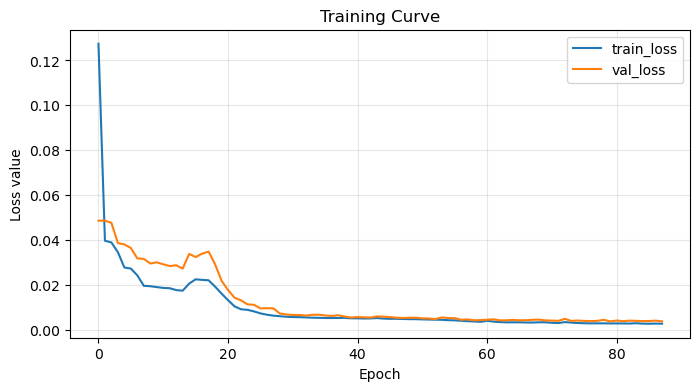

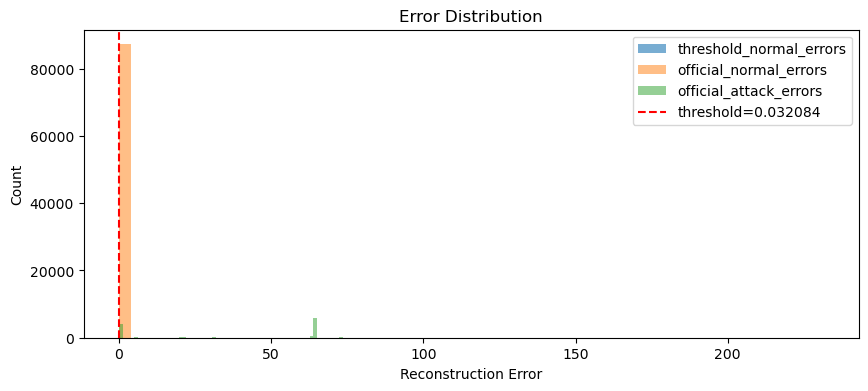

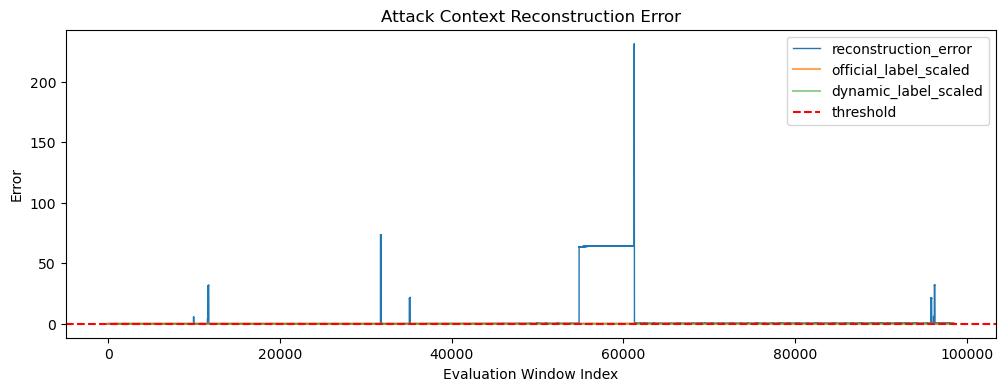

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


positive_errors = evaluation_df.loc[evaluation_df["label"] == 1, "error"]
negative_errors = evaluation_df.loc[evaluation_df["label"] == 0, "error"]

plt.figure(figsize=(10, 4))
plt.hist(threshold_errors, bins=60, alpha=0.6, label="threshold_normal_errors")
plt.hist(negative_errors, bins=60, alpha=0.5, label="official_normal_errors")
plt.hist(positive_errors, bins=60, alpha=0.5, label="official_attack_errors")
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.6f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Error Distribution")
plt.legend()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(evaluation_df["error"].to_numpy(), label="reconstruction_error", linewidth=1)
plt.plot(evaluation_df["label"].to_numpy() * threshold, label="official_label_scaled", alpha=0.7)
plt.plot(evaluation_df["label_dynamic"].to_numpy() * threshold, label="dynamic_label_scaled", alpha=0.5)
plt.axhline(threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("Evaluation Window Index")
plt.ylabel("Error")
plt.title("Attack Context Reconstruction Error")
plt.legend()
plt.show()


In [15]:
# 儲存模型與主要實驗物件
torch.save(best_model.state_dict(), "./results/conv_bilstm_autoencoder.pt")

np.save("./results/attack_errors.npy", attack_errors)
np.save("./results/threshold_errors.npy", threshold_errors)

evaluation_df.to_parquet("./results/evaluation_df.parquet", index=False)
recovery_segments.to_parquet("./results/recovery_segments.parquet", index=False)

# print(f"Saved model and evaluation results to: {RESULT_DIR.resolve()}")